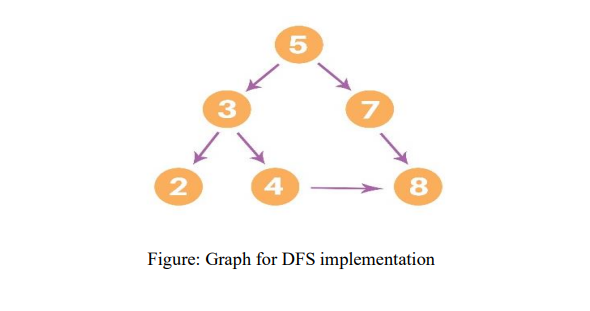

In [3]:
# Using a Python dictionary to act as an adjacency list
graph = {
    '5' : ['3', '7'],
    '3' : ['2', '4'],
    '7' : ['8'],
    '2' : [],
    '4' : ['8'],
    '8' : []
}

# Set to keep track of visited nodes of graph
visited = set()

def dfs(visited, graph, node):
    """
    Function for Depth-First Search.
    It explores as far as possible along each branch before backtracking.
    """
    if node not in visited:
        print(node, end=" ") # Prints on the same line for better readability
        visited.add(node)

        # We use graph.get(node, []) to avoid errors if a node isn't in the dict
        for neighbour in graph.get(node, []):
            dfs(visited, graph, neighbour)

# Driver Code
print("Following is the Depth-First Search:")
dfs(visited, graph, '5')

Following is the Depth-First Search:
5 3 2 4 8 7 

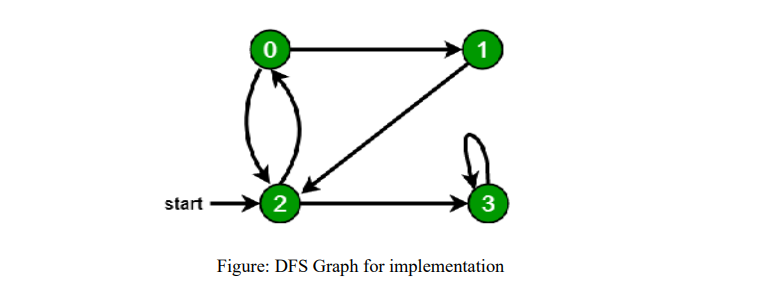

In [6]:
from collections import defaultdict

# This class represents a directed graph using adjacency list representation
class Graph:
    def __init__(self):
        # Default dictionary to store graph
        self.graph = defaultdict(list)

    # Function to add an edge to graph
    def addEdge(self, u, v):
        self.graph[u].append(v)

    # A function used by DFS
    def DFSUtil(self, v, visited):
        # Mark the current node as visited and print it
        visited.add(v)
        print(v, end=" ")

        # Recur for all the vertices adjacent to this vertex
        for neighbour in self.graph[v]:
            if neighbour not in visited:
                self.DFSUtil(neighbour, visited)

    # The function to do DFS traversal.
    # It handles disconnected graphs by checking every node.
    def DFS(self):
        # Use a set for visited to handle any node naming (int or string)
        visited = set()

        # Get all vertices (keys and values) to ensure we don't miss any
        vertices = list(self.graph.keys())
        for node in self.graph:
            for neighbour in self.graph[node]:
                vertices.append(neighbour)

        # Call the recursive helper function for all unvisited vertices
        for vertex in sorted(set(vertices)):
            if vertex not in visited:
                self.DFSUtil(vertex, visited)

# Driver code
g = Graph()
g.addEdge(0, 1)
g.addEdge(0, 2)
g.addEdge(1, 2)
g.addEdge(2, 0)
g.addEdge(2, 3)
g.addEdge(3, 3)

print("Following is Depth First Traversal:")
g.DFS()


Following is Depth First Traversal:
0 1 2 3 

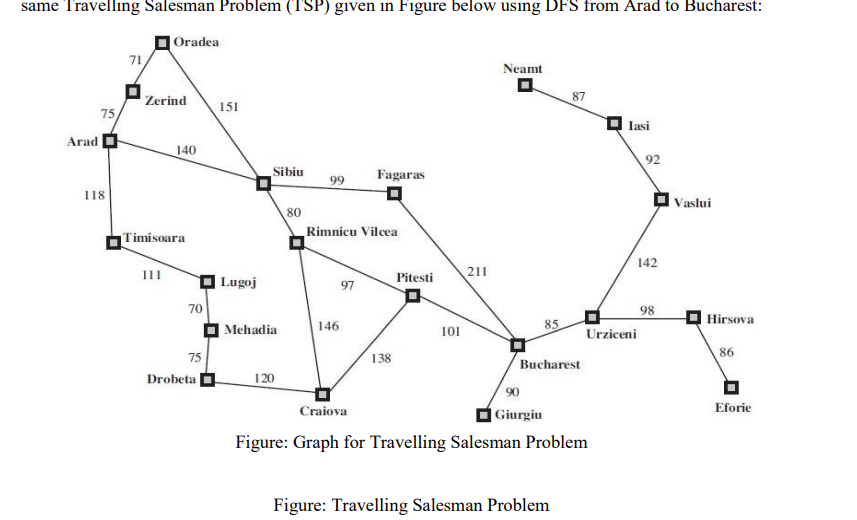

In [7]:
# Lab Task 1: DFS from Arad to Bucharest
graph = {
    'Arad': [('Zerind', 75), ('Sibiu', 140), ('Timisoara', 118)],
    'Zerind': [('Arad', 75), ('Oradea', 71)],
    'Oradea': [('Zerind', 71), ('Sibiu', 151)],
    'Sibiu': [('Arad', 140), ('Oradea', 151), ('Fagaras', 99), ('Rimnicu Vilcea', 80)],
    'Timisoara': [('Arad', 118), ('Lugoj', 111)],
    'Lugoj': [('Timisoara', 118), ('Mehadia', 70)],
    'Mehadia': [('Lugoj', 70), ('Drobeta', 75)],
    'Drobeta': [('Mehadia', 75), ('Craiova', 120)],
    'Craiova': [('Drobeta', 120), ('Rimnicu Vilcea', 146), ('Pitesti', 138)],
    'Rimnicu Vilcea': [('Sibiu', 80), ('Craiova', 146), ('Pitesti', 97)],
    'Fagaras': [('Sibiu', 99), ('Bucharest', 211)],
    'Pitesti': [('Rimnicu Vilcea', 97), ('Craiova', 138), ('Bucharest', 101)],
    'Bucharest': [('Fagaras', 211), ('Pitesti', 101), ('Giurgiu', 90), ('Urziceni', 85)],
    'Giurgiu': [('Bucharest', 90)],
    'Urziceni': [('Bucharest', 85), ('Vaslui', 142), ('Hirsova', 98)],
    'Hirsova': [('Urziceni', 98), ('Eforie', 86)],
    'Eforie': [('Hirsova', 86)],
    'Vaslui': [('Urziceni', 142), ('Iasi', 92)],
    'Iasi': [('Vaslui', 92), ('Neamt', 87)],
    'Neamt': [('Iasi', 87)]
}

def dfs_path(graph, start, goal, visited=None, path=None, distance=0):
    if visited is None:
        visited = set()
    if path is None:
        path = []

    visited.add(start)
    path.append(start)

    # Base Case: Goal reached
    if start == goal:
        return path, distance

    # Recur for neighbors
    for (neighbour, weight) in graph.get(start, []):
        if neighbour not in visited:
            result_path, total_dist = dfs_path(graph, neighbour, goal, visited, path.copy(), distance + weight)
            if result_path: # If goal was found in this branch
                return result_path, total_dist

    return None, 0

# Execution
start_node = 'Arad'
goal_node = 'Bucharest'
final_path, total_distance = dfs_path(graph, start_node, goal_node)

print(f"--- DFS Traversal from {start_node} to {goal_node} ---")
if final_path:
    print("Path taken:", " -> ".join(final_path))
    print(f"Total distance: {total_distance} km")
else:
    print("No path found.")

--- DFS Traversal from Arad to Bucharest ---
Path taken: Arad -> Zerind -> Oradea -> Sibiu -> Fagaras -> Bucharest
Total distance: 607 km


**Lab Task 2:**
Create a graph of the Figure for TSP given above and then set initial and goal states such that the number
of nodes visited for BFS is smaller than that in DFS. Now modify the initial and goal state such that the
number of nodes visited for BFS is larger than that in DFS.

In [11]:
from collections import deque

def bfs_count(graph, start, goal):
    visited = set()
    queue = deque([start])
    visited.add(start)
    count = 0
    while queue:
        node = queue.popleft()
        count += 1
        if node == goal:
            return count
        for neighbor, weight in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return count

# Example Test
# bfs_count(graph, 'Arad', 'Timisoara') will return a small number.
# dfs_count(graph, 'Arad', 'Timisoara') will return a much larger number.